CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64
Mean Squared Error: 24.291119474973538
Mean Absolute Error: 3.1890919658878416
R-squared: 0.6687594935356317


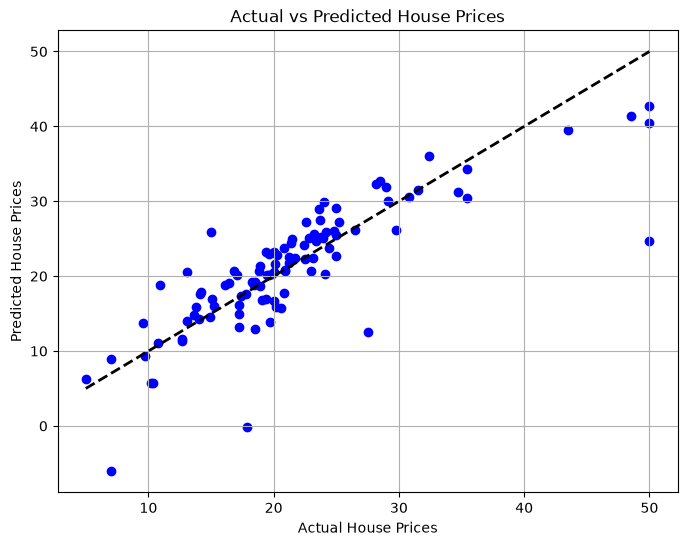

Predicted house price for the new data: 29.942805298376786


c:\Users\kumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [21]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load dataset
df = pd.read_csv('boston.csv')

# Convert all columns to numeric
for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')
    


# Check missing values
print(df.isnull().sum())

# Drop rows with missing values
df= df.dropna()

# Separate features and target
x = df.drop('MEDV', axis=1)
y = df['MEDV'] 

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Create Linear Regression model
model = LinearRegression()

# Train model
model.fit(x_train, y_train)

# Make predictions
y_pred = model.predict(x_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')

# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test , y_pred, color="blue",label="Actual Scores")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label="Predicted Scores")
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')
plt.title('Actual vs Predicted House Prices')
plt.grid(True)
plt.show()

new_house = np.array([[0.1, 18.0, 2.31, 0, 0.538, 6.575, 65.2, 4.09, 1, 296.0, 15.3, 396.9, 4.98]])
prediction = model.predict(new_house)
print(f'Predicted house price for the new data: {prediction[0]}')
    
    


